## Fit log-linear model

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")


def get_all_run_ids():
    return [
        p.stem.replace("bench_speedup_dataset.", "", 1)
        for p in RESULTS_DIR.glob("bench_speedup_dataset.*.csv")
    ]


def get_bench_speedup(run_id):
    return pd.read_csv(f"results/bench_speedup_dataset.{run_id}.csv")


def get_all_records_bench_speedup():
    dfs = []
    for p in RESULTS_DIR.glob("bench_speedup_dataset.*.csv"):
        run_id = p.stem.replace("bench_speedup_dataset.", "", 1)
        df = pd.read_csv(p)
        df["run_id"] = run_id
        dfs.append(df)
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all


df_all_records = get_all_records_bench_speedup()
df_all_records.head()


,n_samples,n_features,n_threads,n_cpus,system,machine,fit_time,predict_time,fit_speedup,predict_speedup,run_id
0,100,10,1,8,Linux,x86_64,0.024420,0.000866,1.000000,1.000000,20260403_083532
1,100,10,2,8,Linux,x86_64,0.034124,0.000763,0.715636,1.134626,20260403_083532
2,100,10,3,8,Linux,x86_64,0.036038,0.000710,0.677631,1.220333,20260403_083532
3,100,10,4,8,Linux,x86_64,0.036264,0.000713,0.673407,1.215421,20260403_083532
4,100,10,5,8,Linux,x86_64,0.038194,0.000709,0.639377,1.220758,20260403_083532


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer


def make_feature_df(X):
    # X is a DataFrame with columns n_samples, n_features, n_threads
    Ls = np.log10(X["n_samples"])
    Lf = np.log10(X["n_features"])
    Lt = np.log10(X["n_threads"])
    return pd.DataFrame(
        {
            "log_n_samples_log_n_threads": Ls * Lt,
            "log_n_features_log_n_threads": Lf * Lt,
            "log_n_threads": Lt,
        },
        index=X.index,
    )


def log_linear_fit(df):
    model = Pipeline(
        [
            ("feat", FunctionTransformer(make_feature_df, validate=False)),
            ("lin", LinearRegression(fit_intercept=False)),
        ]
    )
    X = df[["n_samples", "n_features", "n_threads"]]
    y = np.log10(df["fit_speedup"])
    model.fit(X, y)
    r2 = model.score(X, y)
    a, b, c = model.named_steps["lin"].coef_
    return dict(r2=r2, a=a, b=b, c=c)


def get_log_linear_df():
    run_ids = get_all_run_ids()
    n_threads_cutoff = 4
    records = []
    for run_id in run_ids:
        df = get_bench_speedup(run_id).query(f"n_threads<={n_threads_cutoff}")
        record = log_linear_fit(df)
        record["theta"] = 10 ** (-record["c"])
        record["n_threads_cutoff"] = n_threads_cutoff
        record["run_id"] = run_id
        record["system"] = df["system"].iloc[0]
        record["machine"] = df["machine"].iloc[0]
        record["n_cpus"] = df["n_cpus"].iloc[0]
        records.append(record)
    return pd.DataFrame(records).sort_values(
        by=["system", "machine", "n_cpus"], ignore_index=True
    )


log_linear_df = get_log_linear_df()
log_linear_df

,r2,a,b,c,theta,n_threads_cutoff,run_id,system,machine,n_cpus
0,0.862219,0.396555,0.608842,-2.786061,611.028401,4,20260401_172506,Darwin,arm64,8
1,0.845256,0.300529,0.231455,-1.111325,12.921854,4,20260403_084036,Linux,aarch64,4
2,0.863855,0.355458,0.257805,-1.466577,29.280410,4,20260403_084205,Linux,aarch64,8
3,0.852470,0.353034,0.250652,-1.453534,28.414126,4,20260403_084318,Linux,aarch64,16
4,0.686890,0.354500,0.334276,-1.659340,45.639403,4,20260403_084453,Linux,aarch64,32
5,0.849403,0.222783,0.196285,-0.916304,8.247144,4,20260403_083352,Linux,x86_64,4
6,0.925525,0.251158,0.211130,-0.847562,7.039822,4,20260403_083532,Linux,x86_64,8
7,0.933746,0.283328,0.308310,-1.246754,17.650379,4,20260403_083717,Linux,x86_64,16
8,0.943508,0.297928,0.324309,-1.340503,21.902981,4,20260403_083904,Linux,x86_64,32


## Checking the heuristics for the predicted best n_threads

The log-linear model `log(fit_speedup) = slope log(n_threads)` with `slope = a*log(n_samples) + b*log(n_features) + c`, which is fitted in the region `1 <= n_threads <= 4`, predicts the optimal number of threads as n_threads=1 if slope <0 and n_threads=n_cpus if slope > 0. 

In [3]:
def get_actual_best_n_threads(df_all_records):
    idx = df_all_records.groupby(["run_id", "n_samples", "n_features"])[
        "fit_speedup"
    ].idxmax()
    return (
        df_all_records.loc[
            idx, ["run_id", "n_samples", "n_features", "n_threads", "fit_speedup"]
        ]
        .sort_values(["run_id", "n_samples", "n_features"])
        .reset_index(drop=True)
    )


actual_best_n_threads = get_actual_best_n_threads(df_all_records)
actual_best_n_threads.head()


,run_id,n_samples,n_features,n_threads,fit_speedup
0,20260401_172506,100,10,1,1.000000
1,20260401_172506,100,31,1,1.000000
2,20260401_172506,100,100,1,1.000000
3,20260401_172506,100,316,1,1.000000
4,20260401_172506,100,1000,4,1.132405


In [4]:
def get_current_policy(df_all_records):
    return (
        df_all_records.query("n_threads==n_cpus")[
            ["run_id", "n_samples", "n_features", "n_cpus", "fit_speedup"]
        ]
        .sort_values(["run_id", "n_samples", "n_features"])
        .reset_index(drop=True)
    )


current_policy = get_current_policy(df_all_records)
current_policy.head()


,run_id,n_samples,n_features,n_cpus,fit_speedup
0,20260401_172506,100,10,8,0.109411
1,20260401_172506,100,31,8,0.147828
2,20260401_172506,100,100,8,0.264412
3,20260401_172506,100,316,8,0.557907
4,20260401_172506,100,1000,8,0.937444


In [5]:
def get_predicted_best_n_threads(log_linear_df, df_all_records):
    coefs = log_linear_df[["run_id", "a", "b", "c"]]
    merged = pd.merge(df_all_records, coefs, how="inner", on=["run_id"])
    merged["slope"] = (
        merged["a"] * np.log10(merged["n_samples"])
        + merged["b"] * np.log10(merged["n_features"])
        + merged["c"]
    )
    # nbr of threads when multi-threaded: n_cpus for Linux and 4 for Mac
    merged["n_theads_multi"] = np.where(
        merged["system"] == "Darwin", 4, merged["n_cpus"]
    )
    # slope < 0 => single-threaded and slope > 0 => multi-threaded
    merged["best_n_threads"] = np.where(
        merged["slope"] < 0, 1, merged["n_theads_multi"]
    )
    selected = merged[merged["n_threads"] == merged["best_n_threads"]]
    return (
        selected[
            ["run_id", "n_samples", "n_features", "n_threads", "slope", "fit_speedup"]
        ]
        .sort_values(["run_id", "n_samples", "n_features"])
        .reset_index(drop=True)
    )


predicted_best_n_threads = get_predicted_best_n_threads(log_linear_df, df_all_records)
predicted_best_n_threads.head()

,run_id,n_samples,n_features,n_threads,slope,fit_speedup
0,20260401_172506,100,10,1,-1.384109,1.0
1,20260401_172506,100,31,1,-1.084948,1.0
2,20260401_172506,100,100,1,-0.775268,1.0
3,20260401_172506,100,316,1,-0.471038,1.0
4,20260401_172506,100,1000,1,-0.166426,1.0


In [6]:
def get_compare_best_n_threads(log_linear_df, df_all_records):
    current_policy = get_current_policy(df_all_records)
    actual_best_n_threads = get_actual_best_n_threads(df_all_records)
    predicted_best_n_threads = get_predicted_best_n_threads(
        log_linear_df, df_all_records
    )
    compare_best_n_threads = pd.merge(
        actual_best_n_threads,
        predicted_best_n_threads,
        how="inner",
        on=["run_id", "n_samples", "n_features"],
        suffixes=["_optimal", "_predicted"],
    )
    compare_best_n_threads = pd.merge(
        compare_best_n_threads,
        current_policy.rename(columns={"fit_speedup": "fit_speedup_current"}),
        how="inner",
        on=["run_id", "n_samples", "n_features"],
    )
    return compare_best_n_threads


compare_best_n_threads = get_compare_best_n_threads(log_linear_df, df_all_records)
compare_best_n_threads.head()

,run_id,n_samples,n_features,n_threads_optimal,fit_speedup_optimal,n_threads_predicted,slope,fit_speedup_predicted,n_cpus,fit_speedup_current
0,20260401_172506,100,10,1,1.000000,1,-1.384109,1.0,8,0.109411
1,20260401_172506,100,31,1,1.000000,1,-1.084948,1.0,8,0.147828
2,20260401_172506,100,100,1,1.000000,1,-0.775268,1.0,8,0.264412
3,20260401_172506,100,316,1,1.000000,1,-0.471038,1.0,8,0.557907
4,20260401_172506,100,1000,4,1.132405,1,-0.166426,1.0,8,0.937444


In [7]:
# TODO : plot comparison (scatter one ax per run_id)
# TODO : summary stats
def scatter_fit_speedup_at_best(
    log_linear_df, compare_best_n_threads, run_id, color_by="n_samples"
):
    m = compare_best_n_threads.query(f"run_id=='{run_id}'")
    info = log_linear_df.query(f"run_id=='{run_id}'").to_dict(orient="records")[0]
    title0 = "run_id={run_id}".format(**info)
    title1 = "{system} {machine} {n_cpus}cpus".format(**info)
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.8), sharey=True)

    sc0 = axes[0].scatter(
        m["fit_speedup_optimal"],
        m["fit_speedup_predicted"],
        c=m[color_by],
        cmap="viridis",
        s=20,
        alpha=0.7,
    )
    fig.colorbar(sc0, ax=axes[0], label=color_by)

    lo = 1 / 4
    hi = 4
    axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("optimal fit_speedup (best n_threads)")
    axes[0].set_ylabel("fit_speedup (predicted best n_threads")
    axes[0].grid(True, which="both", alpha=0.3)
    axes[0].set_title(title0)

    sc1 = axes[1].scatter(
        m["fit_speedup_current"],
        m["fit_speedup_predicted"],
        c=m[color_by],
        cmap="viridis",
        s=20,
        alpha=0.7,
    )
    fig.colorbar(sc1, ax=axes[1], label=color_by)
    axes[1].plot([lo, hi], [lo, hi], "k--", lw=1)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("current fit_speedup (n_threads = n_cpus)")
    axes[1].grid(True, which="both", alpha=0.3)
    axes[1].set_title(title1)

    fig.tight_layout()
    return fig

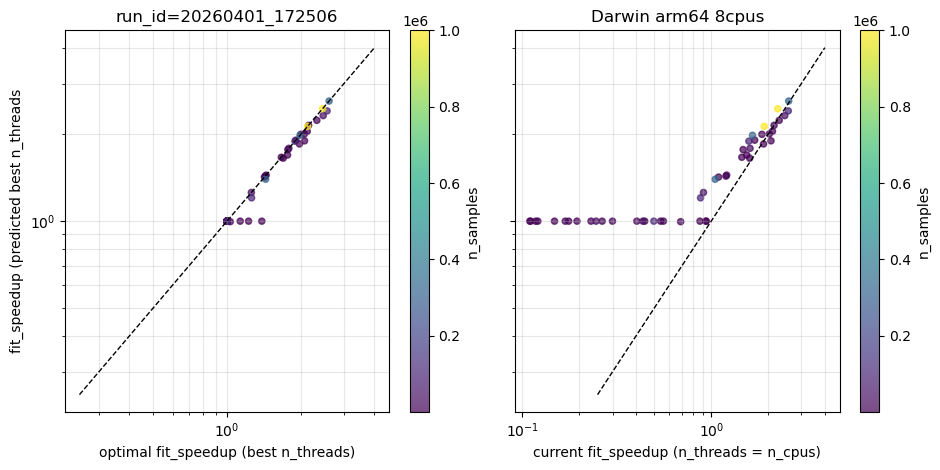

In [8]:
# mac 8 cpus
scatter_fit_speedup_at_best(
    log_linear_df,
    compare_best_n_threads,
    run_id="20260401_172506",
    color_by="n_samples",
);


In [9]:
from matplotlib.backends.backend_pdf import PdfPages


def make_loglinear_fit_all(log_linear_df, compare_best_n_threads):
    out_path = RESULTS_DIR / "loglinear_fit_all.pdf"
    run_ids = log_linear_df["run_id"]
    with PdfPages(out_path) as pdf:
        for run_id in run_ids:
            fig = scatter_fit_speedup_at_best(
                log_linear_df,
                compare_best_n_threads,
                run_id=run_id,
                color_by="n_samples",
            )
            pdf.savefig(fig, dpi=150)
            plt.close(fig)


make_loglinear_fit_all(log_linear_df, compare_best_n_threads)